# Modelos de previsão da melhor cultura para determinados tipos de solo

O seguinte notebook avalia cinco modelos de previsão de qual seria a melhor cultura a ser plantada em um solo com determinadas propriedades, como teor de NPK e pH, e condições atmosféricas como temperatura, umidade e índice de precipitação.

## Preparação

Começamos importando todas as bibliotecas necessárias.

Depois, carregamos o arquivo csv que contém os dados em um DataFrame "df".

Por fim, mostramos o comecinho do DataFrame para verificar se o carregamento ocorreu bem, e termos uma intuição visual de como são os dados, como o nome das colunas e quais os tipos dos dados de cada coluna.

In [1]:
# Importações das ferramentas necessárias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Carregar o dataset
df = pd.read_csv("produtos_agricolas.csv")
# Certificando que o carregamento ocorreu bem
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


O resultado acima mostra que temos as colunas "N", "P", "K", "temperature", "humidity", "ph" e "rainfall" como variáveis independentes (_features_) e a coluna "label" como variável dependente (_target_).

---

## Limpeza e tratamento

Agora vamos verificar se há dados ausentes e quais os tipos dos dados de cada coluna.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


Vemos que felizmente não há dados ausentes e que as colunas são do tipo inteiro, float ou string.

Abaixo, vamos ver como os dados estão distribuidos a fim de entender se _outliers_ devem ser tratados, e qual a frequência de ocorrência da coluna "label" para saber se a acurácia será uma métrica relevante.

Número de dados duplicados: 0


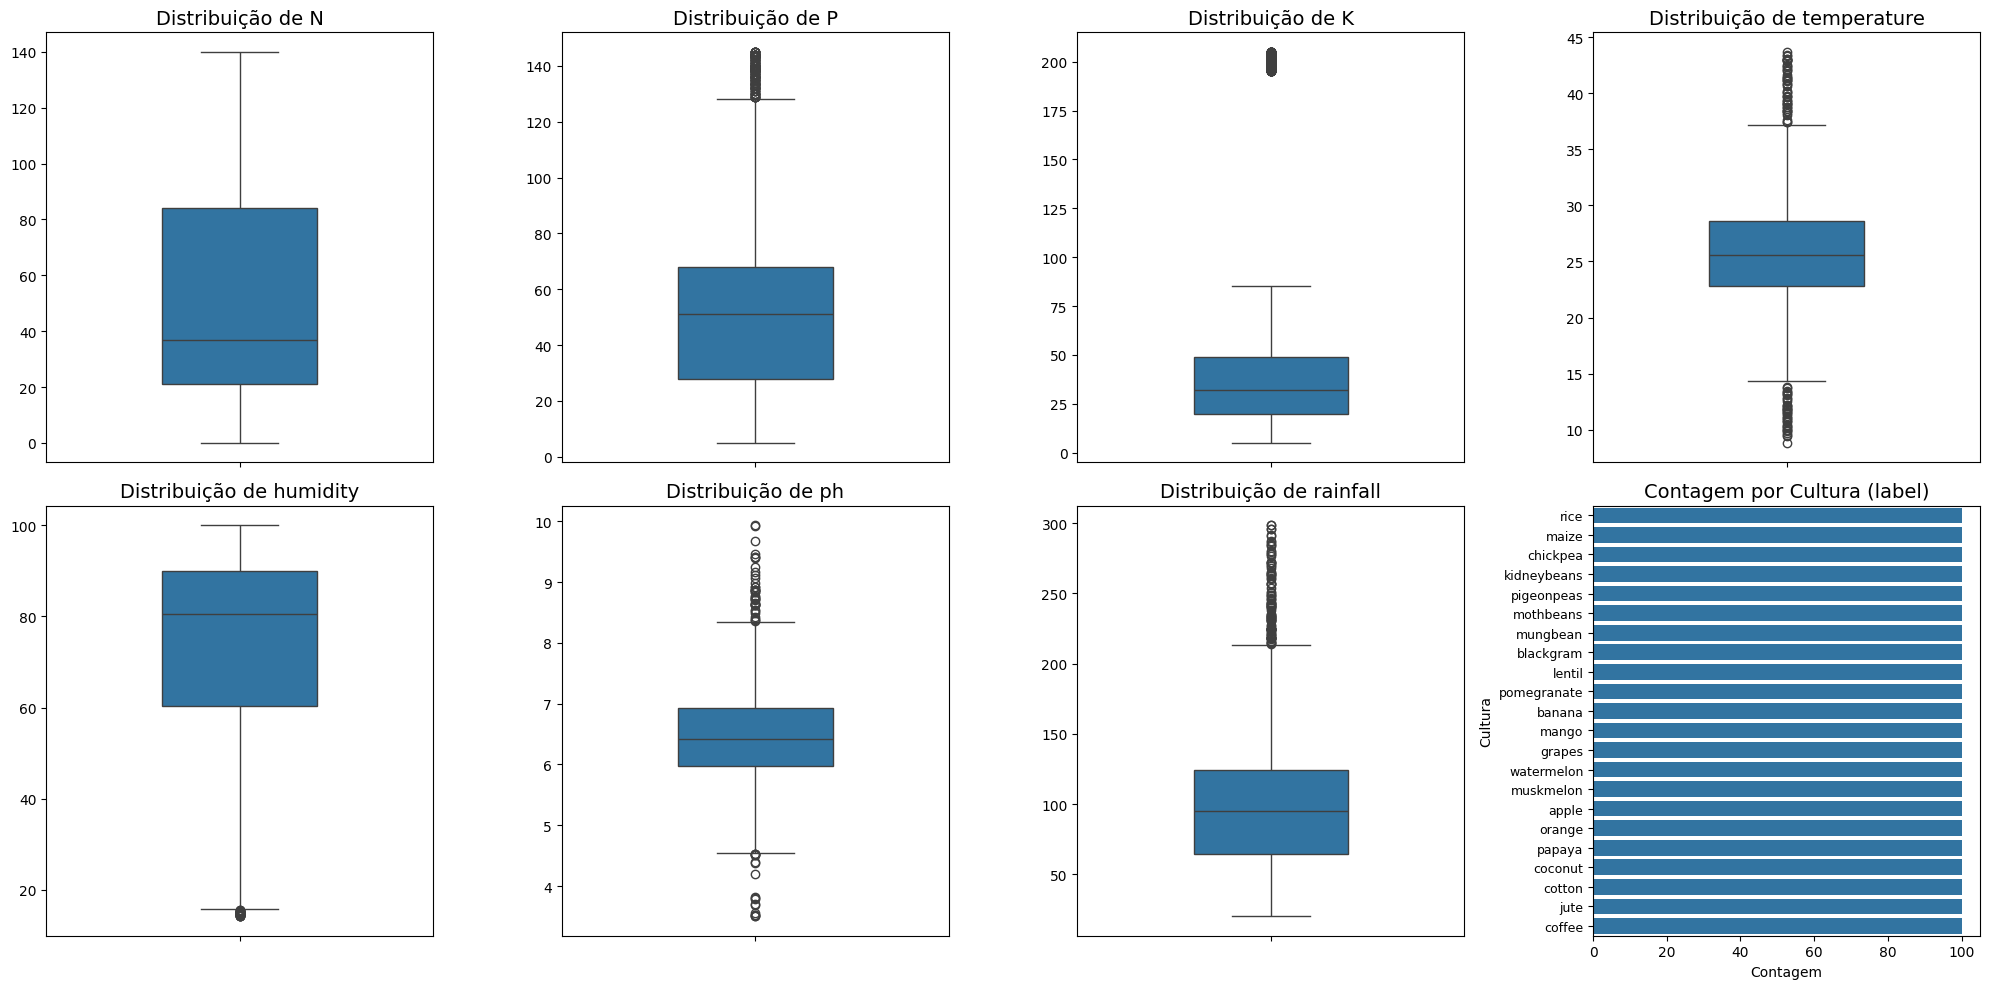

In [3]:
# Verificar a presença de dados duplicados
duplicates = df.duplicated().sum()
print("Número de dados duplicados:", duplicates)

# --------------------------------
# Verificar a presença de outliers
# --------------------------------

# Identificar as colunas numéricas para nomeá-las nos boxplots
numeric_cols = df.drop(columns=['label']).columns

# Criar a figura e os eixos (subplots)
# 2 linhas, 4 colunas
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))

# Converter o array de eixos de 2D para 1D
axes = axes.flatten()

# Iterar sobre as colunas numéricas e os eixos ao mesmo tempo para desenhar os boxplots
for i, col_name in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col_name, ax=axes[i], width=0.4)
    axes[i].set_title(f'Distribuição de {col_name}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# ----------------------------------------------------------
# Verificar a distribuição das ocorrências da coluna "label"
# ----------------------------------------------------------

# Usar o oitavo eixo (índice 7) para o countplot das ocorrências da coluna "label"
ax_count = axes[7]

# Plotar horizontalmente (y='label') é melhor para 22 labels
sns.countplot(data=df, y='label', ax=ax_count)

ax_count.set_title('Contagem por Cultura (label)', fontsize=14)
ax_count.set_xlabel('Contagem', fontsize=10)
ax_count.set_ylabel('Cultura', fontsize=10)
# Ajustar o tamanho da fonte dos rótulos Y se forem muitos
ax_count.tick_params(axis='y', labelsize=9)

# Ajustar o layout para evitar sobreposição
plt.tight_layout()

Tivemos alguns _insights_ interessantes.

Primeiro, a coluna "K" (potássio) parece ter outliers.

Segundo, todas as label ocorrem 100 vezes, ou seja, a acurácia será uma boa métrica.

Vamos analisar melhor os valores de potássio para nos assegurar de que se trata ou não de outliers. Plotarei as distribuições dos valores de potássio por cultura.

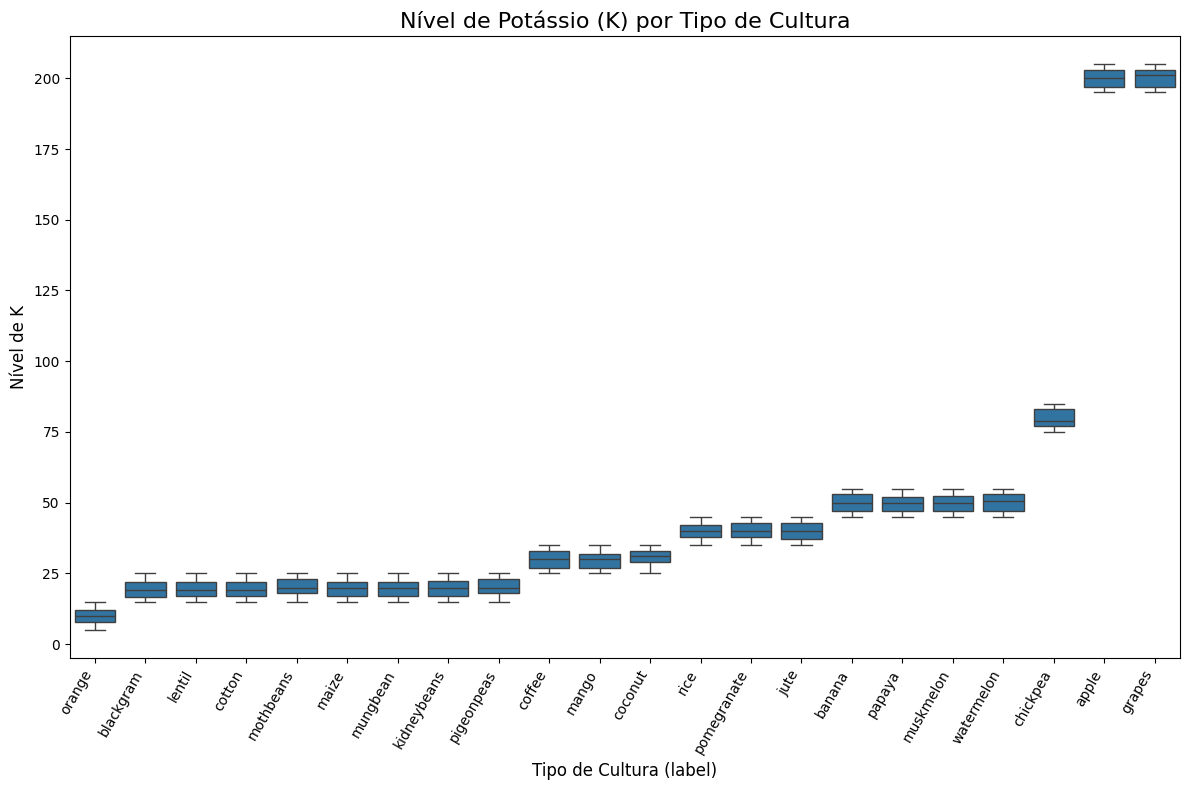

In [4]:
# Criando boxplots de 'K' para cada 'label' (tipo de cultura)

plt.figure(figsize=(12, 8)) # Criação do espaço de plot

order = df.groupby('label')['K'].median().sort_values().index # Ordenar os labels pela mediana de K para melhor visualização

sns.boxplot(x='label', y='K', data=df, order=order) # Criação do plot
plt.title('Nível de Potássio (K) por Tipo de Cultura', fontsize=16)
plt.xlabel('Tipo de Cultura (label)', fontsize=12)
plt.ylabel('Nível de K', fontsize=12)
plt.xticks(rotation=60, ha='right')

plt.tight_layout() # Ajuste para evitar sobreposições

Com este gráfico podemos ver que os valores extremos de potássio não se tratam de _outliers_, mas sim uma necessidade intrínseca das culturas de maçã e uva.

Desta forma, não há necessidade de limpeza.

Continuemos com a avaliação de correlação entre as variáveis. Caso alguma variável se correlacione fortemente com outra, são redundantes e uma delas pode ser eliminada, reduzindo assim o custo computacional do modelo.

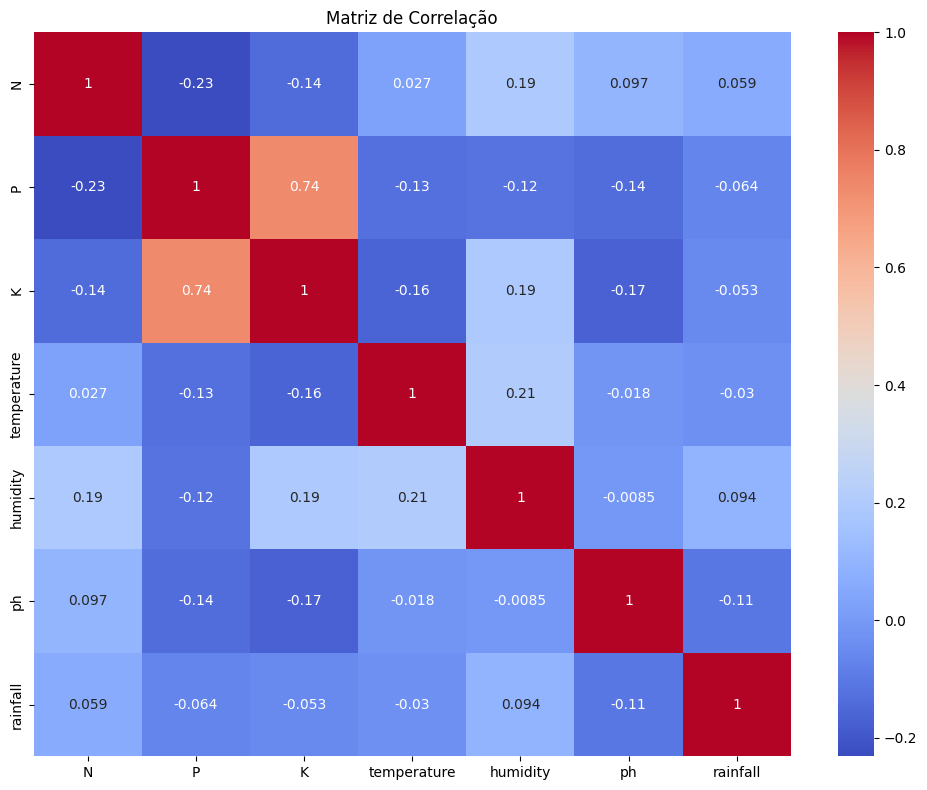

In [5]:
corr_matrix = df.corr(numeric_only=True) # Definição da matriz de correlação

plt.figure(figsize=(10, 8)) # Definição do tamanho do plot

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de Correlação') # Estabelecimento do titulo do plot

plt.tight_layout() # Ajuste de formatação

Podemos ver que há correlação significativa entre fósforo (P) e potássio (K), mas não alta o suficiente que justifique a remoção de uma delas. Portanto, seguimos sem alteração.

---

## Engenharia de _features_

Vamos primeiro separar _features_ do _target_.

Depois converter o _target_ para valores numéricos.

Depois dividimos os dados em treinamento e teste.

E por fim normalizamos as _features_.

In [6]:
features = df.drop(columns=['label']) # DataFrame das variáveis
target = df['label'] # DataFrame do alvo

# Tratamento do target
label_encoder = LabelEncoder() # Criação de um objeto encoder
label_encoder.fit(target) # Ajuste do encoder aos dados do target
y = label_encoder.transform(target) # Aplicação do encoder no target

# Dividindo os dados em treinamento e teste, dividindo igualmente para cada label possível
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42, stratify=y)

# Normalização das features
scaler = MinMaxScaler() # Criação de um objeto scaler
scaler.fit(X_train) # Ajuste do scaler as features de treinamento
X_train_scaled = scaler.transform(X_train) # Aplicação do scaler nas features de treinamento
X_test_scaled = scaler.transform(X_test) # Aplicação do scaler nas features de teste

## Construção dos modelos preditivos

Com os dados de treinamento e teste devidamente tratados, vamos dar início ao desenvolvimento de 5 modelos preditivos com algorítmos diferentes.

### Regressão Logística:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.87      1.00      0.93        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      0.80      0.89        20
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.89      0.85      0.87        20
       maize       1.00      0.85      0.92        20
       mango       0.83      1.00      0.91        20
   mothbeans       0.88      0.75      0.81        20
    mungbean       0.91      1.00      0.95        20
   muskmelon       0.91      1.00      0.95        20
      orange       1.00      0.90      0.95        20
      papaya       0.94    

Text(0.5, 1.0, 'Matriz de Confusão Normalizada (Sensibilidade)')

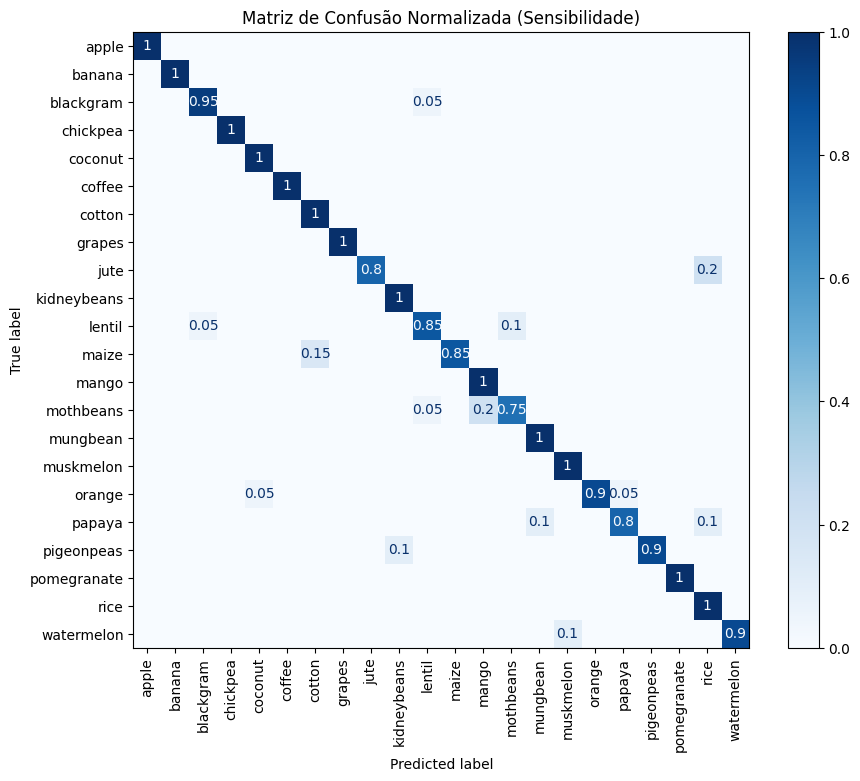

In [7]:
log_reg = LogisticRegression() # Criação do modelo
log_reg.fit(X_train_scaled, y_train) # Treinamento do modelo
y_pred_log_reg = log_reg.predict(X_test_scaled) # Predição do modelo

# Visualização das métricas de performance
print(classification_report(y_test, y_pred_log_reg, target_names=label_encoder.classes_))

# Visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_reg,
    display_labels=label_encoder.classes_,
    normalize='true',
    cmap='Blues',
    ax=ax
)

# Remoção dos 0s para melhor legibilidade
for i in range(22):
    for j in range(22):
        # Se o valor na matriz for 0...
        if display.confusion_matrix[i, j] == 0:
            # Define o texto do objeto correspondente como uma string vazia
            display.text_[i, j].set_text("")

plt.xticks(rotation=90)
display.ax_.set_title('Matriz de Confusão Normalizada (Sensibilidade)')


### K Nearest Neighbors:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.87      1.00      0.93        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.90      0.92        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      0.90      0.95        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

Text(0.5, 1.0, 'Matriz de Confusão Normalizada (Sensibilidade)')

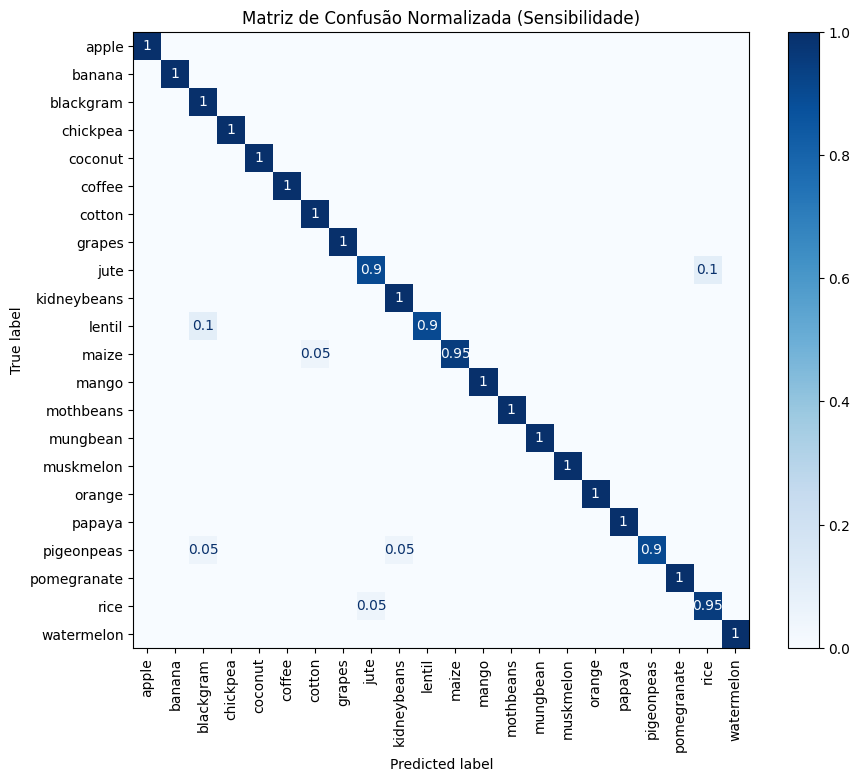

In [8]:
knn = KNeighborsClassifier() # Criação do modelo
knn.fit(X_train_scaled, y_train) # Treinamento do modelo
y_pred_knn = knn.predict(X_test_scaled) # Predição do modelo

# Visualização das métricas de performance
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

# Visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=label_encoder.classes_,
    normalize='true',
    cmap='Blues',
    ax=ax
)

# Remoção dos 0s para melhor legibilidade
for i in range(22):
    for j in range(22):
        # Se o valor na matriz for 0...
        if display.confusion_matrix[i, j] == 0:
            # Define o texto do objeto correspondente como uma string vazia
            display.text_[i, j].set_text("")

plt.xticks(rotation=90)
display.ax_.set_title('Matriz de Confusão Normalizada (Sensibilidade)')

### Support Vector Machine:

#### Linear kernel:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.83      0.95      0.88        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       0.80      1.00      0.89        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.89      0.80      0.84        20
       maize       1.00      0.90      0.95        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.95      0.90      0.92        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

Text(0.5, 1.0, 'Matriz de Confusão Normalizada (Sensibilidade)')

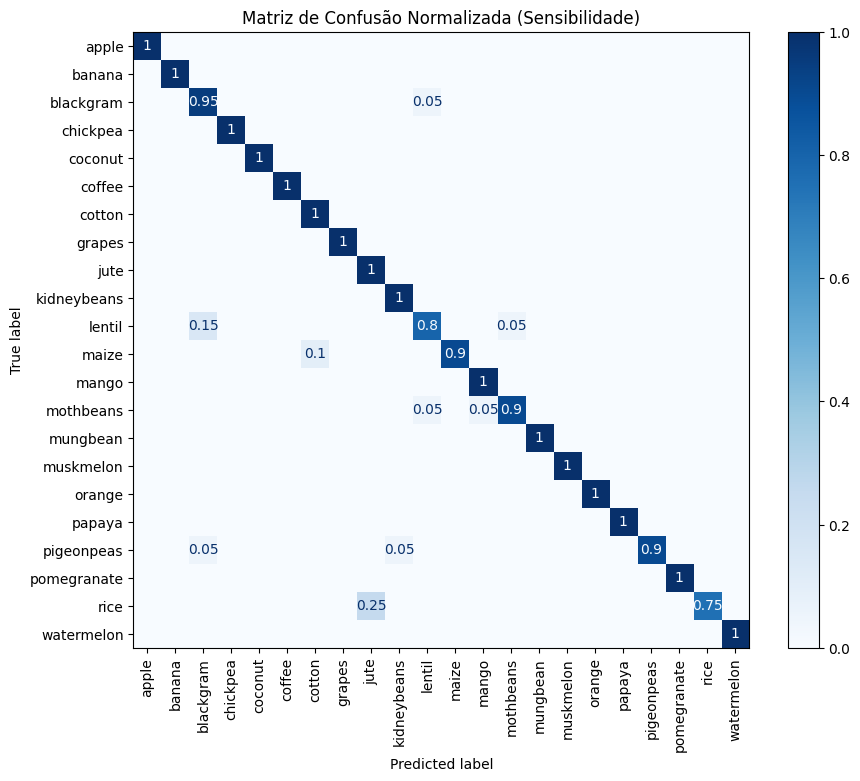

In [9]:
svm_linear = SVC(kernel='linear') # Criação do modelo
svm_linear.fit(X_train_scaled, y_train) # Treinamento do modelo
y_pred_svm_linear = svm_linear.predict(X_test_scaled) # Predição do modelo

# Visualização das métricas de performance
print(classification_report(y_test, y_pred_svm_linear, target_names=label_encoder.classes_))

# Visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_linear,
    display_labels=label_encoder.classes_,
    normalize='true',
    cmap='Blues',
    ax=ax
)

# Remoção dos 0s para melhor legibilidade
for i in range(22):
    for j in range(22):
        # Se o valor na matriz for 0...
        if display.confusion_matrix[i, j] == 0:
            # Define o texto do objeto correspondente como uma string vazia
            display.text_[i, j].set_text("")

plt.xticks(rotation=90)
display.ax_.set_title('Matriz de Confusão Normalizada (Sensibilidade)')

#### Poly kernel:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.90      0.95        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

Text(0.5, 1.0, 'Matriz de Confusão Normalizada (Sensibilidade)')

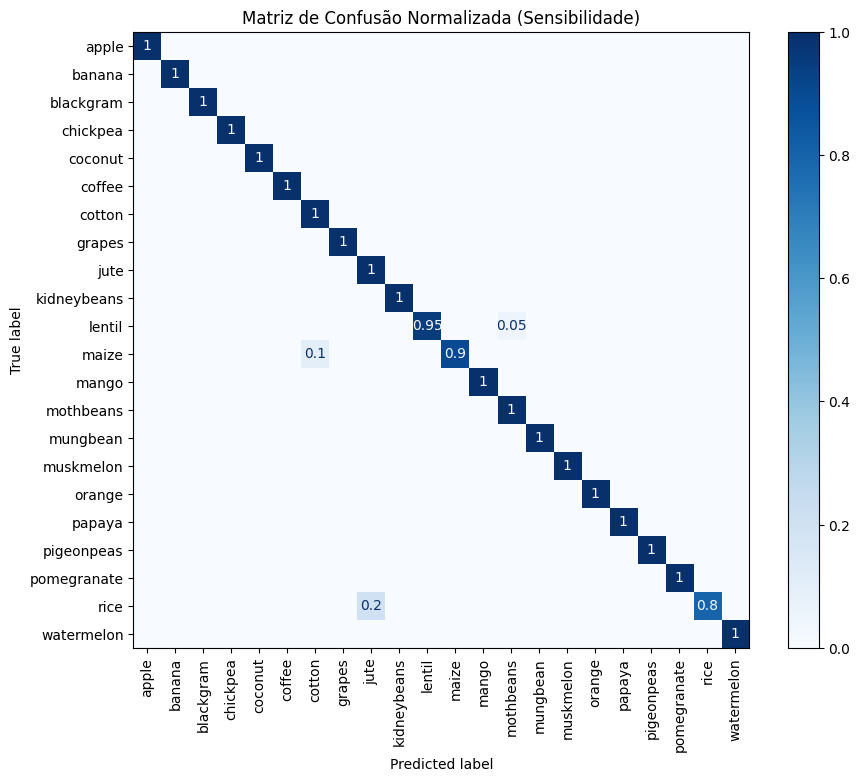

In [10]:
svm_poly = SVC(kernel='poly') # Criação do modelo
svm_poly.fit(X_train_scaled, y_train) # Treinamento do modelo
y_pred_svm_poly = svm_poly.predict(X_test_scaled) # Predição do modelo

# Visualização das métricas de performance
print(classification_report(y_test, y_pred_svm_poly, target_names=label_encoder.classes_))

# Visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_poly,
    display_labels=label_encoder.classes_,
    normalize='true',
    cmap='Blues',
    ax=ax
)

# Remoção dos 0s para melhor legibilidade
for i in range(22):
    for j in range(22):
        # Se o valor na matriz for 0...
        if display.confusion_matrix[i, j] == 0:
            # Define o texto do objeto correspondente como uma string vazia
            display.text_[i, j].set_text("")

plt.xticks(rotation=90)
display.ax_.set_title('Matriz de Confusão Normalizada (Sensibilidade)')

#### RBF kernel:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

Text(0.5, 1.0, 'Matriz de Confusão Normalizada (Sensibilidade)')

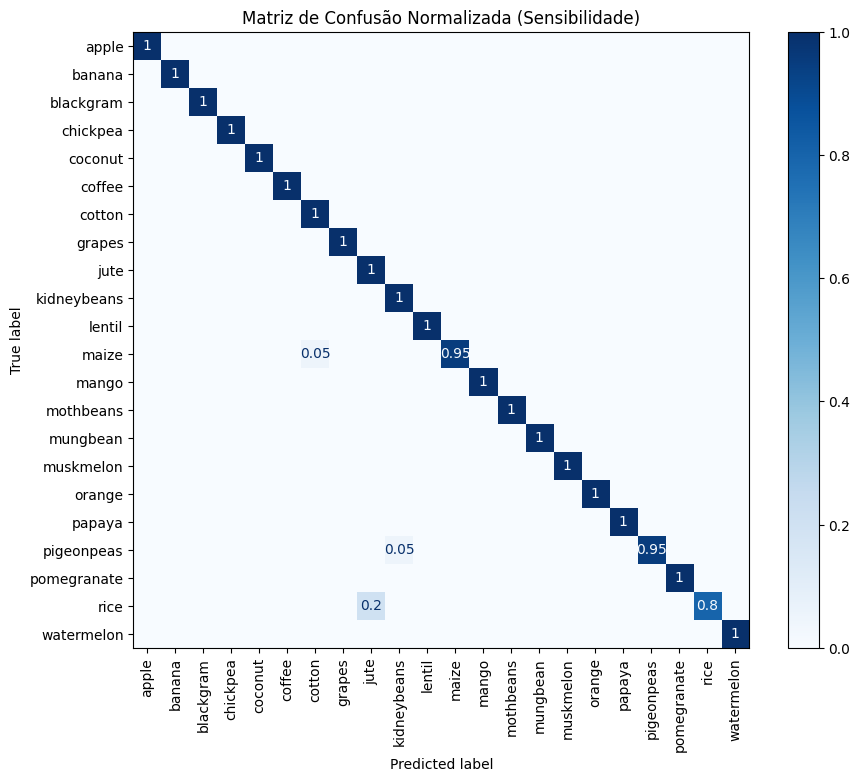

In [11]:
svm_rbf = SVC(kernel='rbf') # Criação do modelo
svm_rbf.fit(X_train_scaled, y_train) # Treinamento do modelo
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled) # Predição do modelo

# Visualização das métricas de performance
print(classification_report(y_test, y_pred_svm_rbf, target_names=label_encoder.classes_))

# Visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_rbf,
    display_labels=label_encoder.classes_,
    normalize='true',
    cmap='Blues',
    ax=ax
)

# Remoção dos 0s para melhor legibilidade
for i in range(22):
    for j in range(22):
        # Se o valor na matriz for 0...
        if display.confusion_matrix[i, j] == 0:
            # Define o texto do objeto correspondente como uma string vazia
            display.text_[i, j].set_text("")

plt.xticks(rotation=90)
display.ax_.set_title('Matriz de Confusão Normalizada (Sensibilidade)')

### Modelos de árvores:

#### Árvore de decisão:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.90      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.90      0.92        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

Text(0.5, 1.0, 'Matriz de Confusão Normalizada (Sensibilidade)')

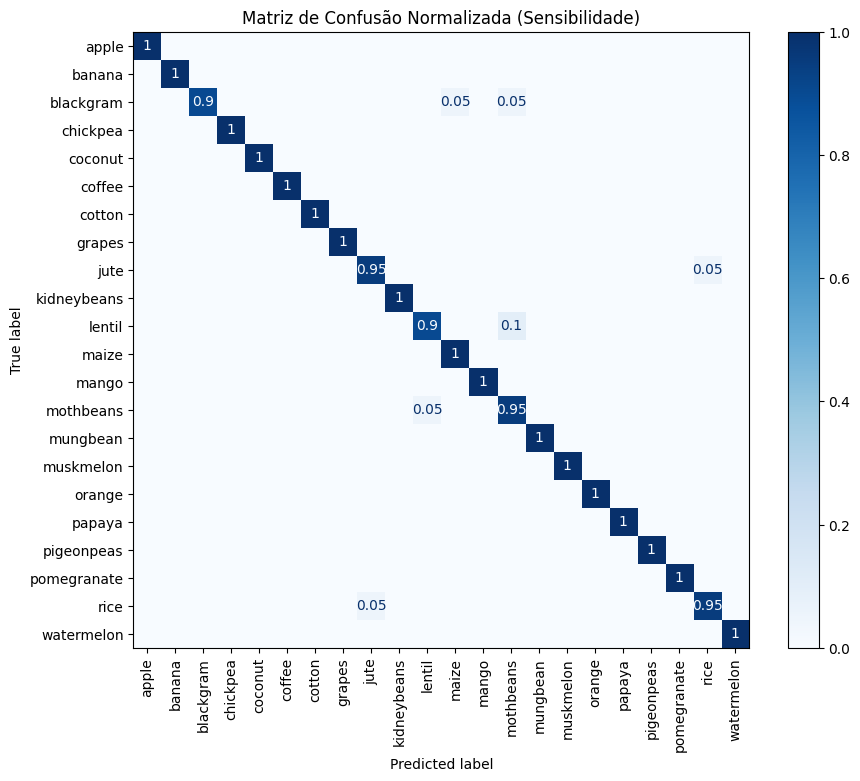

In [12]:
decision_tree = DecisionTreeClassifier() # Criação do modelo
decision_tree.fit(X_train_scaled, y_train) # Treinamento do modelo
y_pred_decision_tree = decision_tree.predict(X_test_scaled) # Predição do modelo

# Visualização das métricas de performance
print(classification_report(y_test, y_pred_decision_tree, target_names=label_encoder.classes_))

# Visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_decision_tree,
    display_labels=label_encoder.classes_,
    normalize='true',
    cmap='Blues',
    ax=ax
)

# Remoção dos 0s para melhor legibilidade
for i in range(22):
    for j in range(22):
        # Se o valor na matriz for 0...
        if display.confusion_matrix[i, j] == 0:
            # Define o texto do objeto correspondente como uma string vazia
            display.text_[i, j].set_text("")

plt.xticks(rotation=90)
display.ax_.set_title('Matriz de Confusão Normalizada (Sensibilidade)')

#### Floresta Aleatória:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

Text(0.5, 1.0, 'Matriz de Confusão Normalizada (Sensibilidade)')

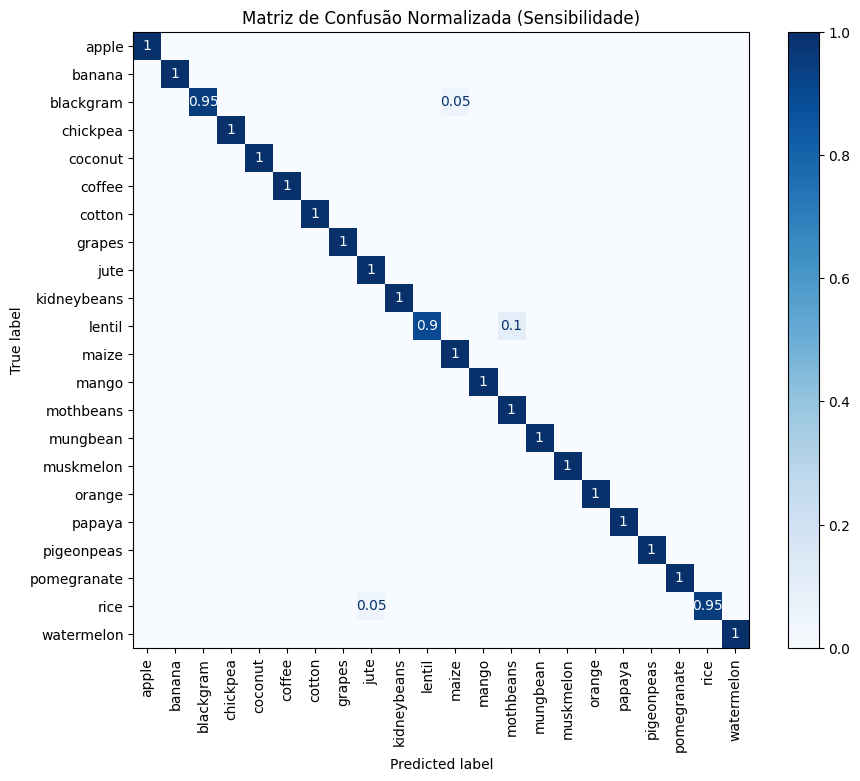

In [13]:
random_forest = RandomForestClassifier() # Criação do modelo
random_forest.fit(X_train_scaled, y_train) # Treinamento do modelo
y_pred_random_forest = random_forest.predict(X_test_scaled) # Predição do modelo

# Visualização das métricas de performance
print(classification_report(y_test, y_pred_random_forest, target_names=label_encoder.classes_))

# Visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_random_forest,
    display_labels=label_encoder.classes_,
    normalize='true',
    cmap='Blues',
    ax=ax
)

# Remoção dos 0s para melhor legibilidade
for i in range(22):
    for j in range(22):
        # Se o valor na matriz for 0...
        if display.confusion_matrix[i, j] == 0:
            # Define o texto do objeto correspondente como uma string vazia
            display.text_[i, j].set_text("")

plt.xticks(rotation=90)
display.ax_.set_title('Matriz de Confusão Normalizada (Sensibilidade)')

## Análise dos resultados

Depois de produzir e testar os modelos, agora vamos analisar os resultados de F1-score e a matriz de confusão de sensibilidade (_recall_).

Como o dataset é perfeitamente balanceado, 100 ocorrências de cada uma das plantações possíveis, a acurácia é matemáticamente idêntica à média dos _recalls_ (Recall Macro). Além disso, não há viés de erros, ou seja, a quantidade de falsos positivos é muito próxima de falsos negativos, o que faz os valores de precisão e recall serem muito proximos, e por isso, muito proximos ao F1-score.

Desta forma, **acurácia = recall médio = precisão média = F1-score médio**.

Então vamos escolher uma dessas medidas para ranquear os modelos e desempatá-los pelo que tem o maior recall mínimo (ou seja, que tem a maior pior performance dentre os labels):

|Modelo|Média F1-score|Menor recall|
|------|:------------:|:----------:|
|Reg Logística  |94%    |80%    |
|KNN            |98%    |**90%**|
|SVM linear     |96%    |75%    |
|SVM poly       |98%    |80%    |
|SVM RBF        |**99%**|80%    |
|Árv. Decisão   |98%    |**90%**|
|Floresta Aleat.|**99%**|**90%**|

Podemos ver na tabela que o melhor modelo foi a Floresta Aleatória, com F1-score médio de 99% e recall mínimo de 90%.

Há um detalhe interessante: todos os modelos performaram não tão bem no par arroz x juta. Ora o arroz teve recall ruim por conta da juta, ora o contrário.

## Análise do perfil de solo do arroz, maça e uva

Devido ao comportamento anômalo da maça e da uva com relação a necessidade de potássio e a dificuldade de todos os modelos com o par arroz e juta, vou escolhê-los para uma análise mais aprofundada.

Vamos ver como se comportam todas as variáveis em cada uma dessas culturas.

### Arroz:

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

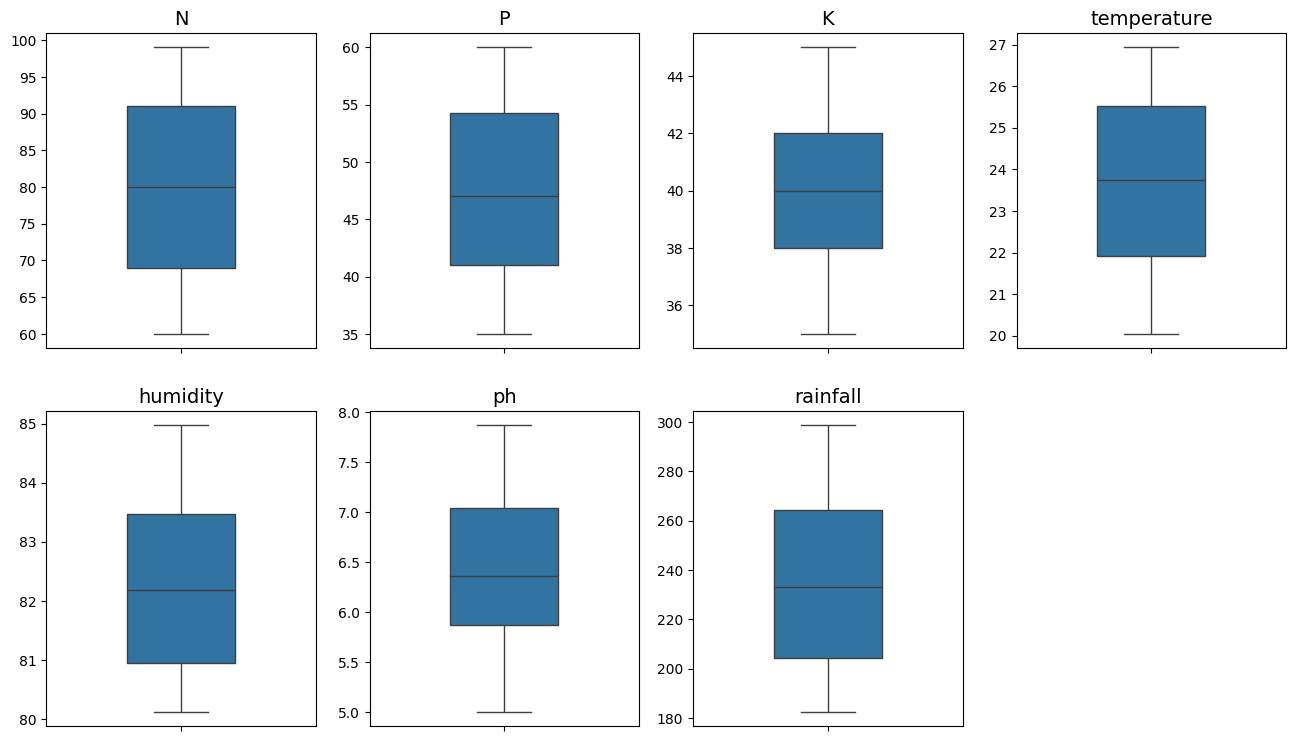

In [14]:
# Filtrar o dataset pela plantação de arroz
data = df[df['label'] == 'rice']
# Tirar a coluna label
data = data.drop(columns=['label'])

# Criar a figura e os eixos (subplots)
# 2 linhas, 4 colunas
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 9))

# Converter o array de eixos de 2D para 1D
axes = axes.flatten()

# Iterar sobre as colunas numéricas e os eixos ao mesmo tempo para desenhar os boxplots
for i, col_name in enumerate(data.columns):
    sns.boxplot(data=data, y=col_name, ax=axes[i], width=0.4)
    axes[i].set_title(f'{col_name}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off') # Ocultar o plot vazio

Acima podemos ver que a plantação de arroz tem uma necessidade hidrica muito maior do que o dos dois seguintes.

### Maça:

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

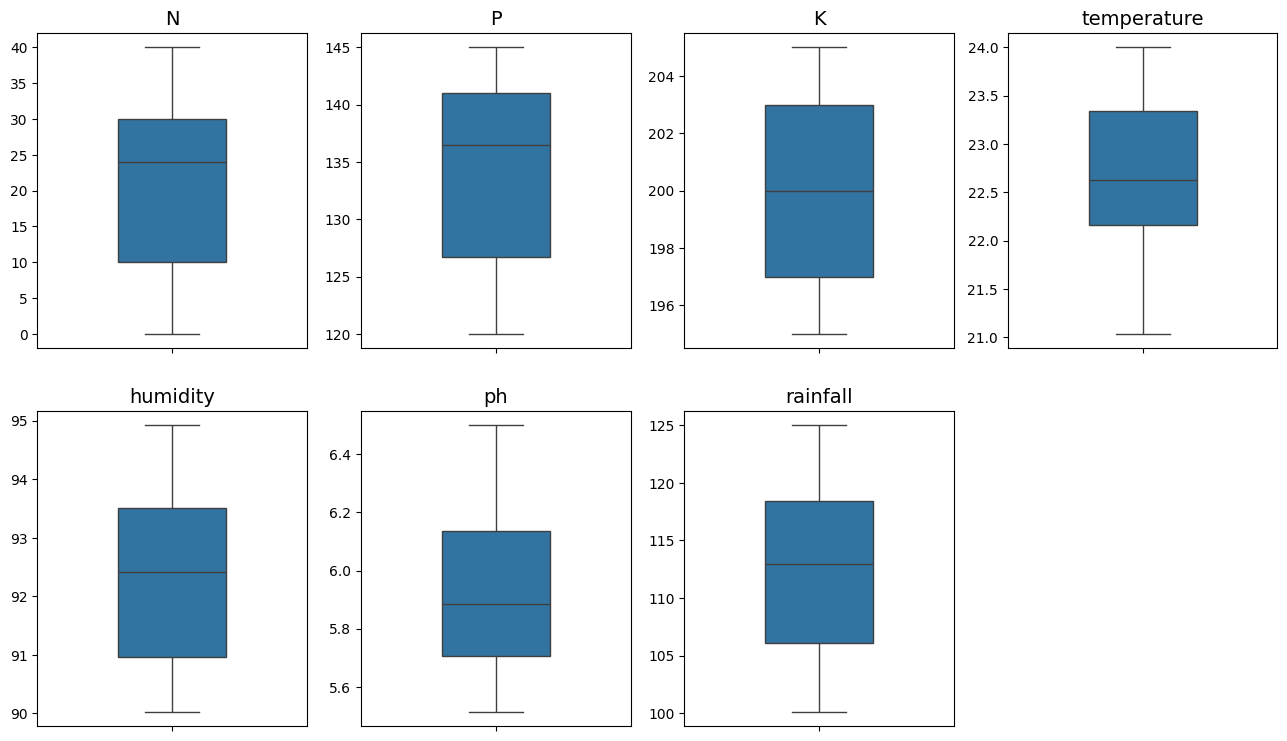

In [15]:
# Filtrar o dataset pela plantação de arroz
data = df[df['label'] == 'apple']
# Tirar a coluna label
data = data.drop(columns=['label'])

# Criar a figura e os eixos (subplots)
# 2 linhas, 4 colunas
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 9))

# Converter o array de eixos de 2D para 1D
axes = axes.flatten()

# Iterar sobre as colunas numéricas e os eixos ao mesmo tempo para desenhar os boxplots
for i, col_name in enumerate(data.columns):
    sns.boxplot(data=data, y=col_name, ax=axes[i], width=0.4)
    axes[i].set_title(f'{col_name}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off') # Ocultar o plot vazio

Acima vemos a grande necessidade de potássio (~195 - ~205)

### Uva:

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

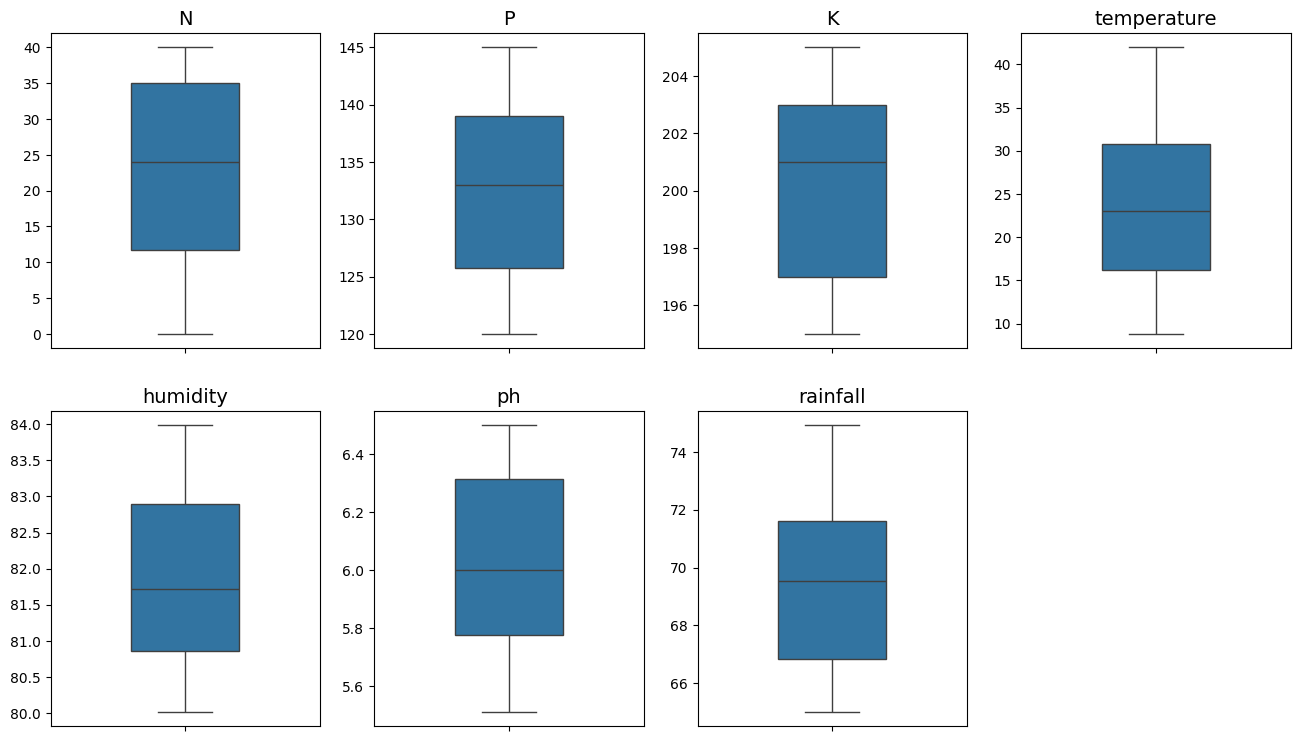

In [16]:
# Filtrar o dataset pela plantação de arroz
data = df[df['label'] == 'grapes']
# Tirar a coluna label
data = data.drop(columns=['label'])

# Criar a figura e os eixos (subplots)
# 2 linhas, 4 colunas
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 9))

# Converter o array de eixos de 2D para 1D
axes = axes.flatten()

# Iterar sobre as colunas numéricas e os eixos ao mesmo tempo para desenhar os boxplots
for i, col_name in enumerate(data.columns):
    sns.boxplot(data=data, y=col_name, ax=axes[i], width=0.4)
    axes[i].set_title(f'{col_name}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[7].axis('off') # Ocultar o plot vazio

Acima vemos exatamente o mesmo para a uva (potássio entre ~195 e ~205)